# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/muneebulhaq02/flyrank-ml-internship/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [16]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/muneebulhaq02/flyrank-ml-internship"
REPO_DIR = "FlyRank-Internship"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())

Working dir: /content/FlyRank-Internship/FlyRank-Internship/FlyRank-Internship


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

This project uses a Random Forest Classifier for the Content Refresh Prioritization lane. The objective is to identify content pages that are likely to require review because they show signs of declining performance.

Random Forest was selected because it can learn complex and non-linear relationships between multiple search performance signals without requiring extensive feature engineering. It is also robust to noisy data, handles missing values after simple preprocessing, and provides feature importance scores that help explain which signals contribute most to the prediction.

The transparent rule-based baseline developed in ML-07 is used as a reference. Both approaches are evaluated on the same prediction task so that the improvement provided by machine learning can be measured fairly.

In [17]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ## Method Choice
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    ConfusionMatrixDisplay
)

np.random.seed(42)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## Split Design

An 80% training split and a 20% testing split are used for model evaluation. The split is stratified by the target label so that both training and testing datasets contain a similar proportion of declining and non-declining pages.

The same feature set and evaluation split are used for both the baseline rule and the Random Forest model. This makes the comparison fair because both methods are evaluated on identical observations. Only features available before the prediction point are included, while label-derived columns, identifiers, and future information are excluded to reduce data leakage.

In [18]:
numeric_features = [
    "impressions_90d",
    "clicks_90d",
    "ctr",
    "avg_position",
    "content_age_days",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct"
]

categorical_features = [
    "content_type",
    "main_intent",
    "competition_level"
]

X = pd.get_dummies(
    df[numeric_features + categorical_features],
    columns=categorical_features,
    drop_first=True
)

X = X.fillna(0)

# Target (derived from trend_direction because no label exists)
y = (df["trend_direction"] == "down").astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Number of features:", X.shape[1])

Training rows: 24000
Testing rows: 6000
Number of features: 20


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

## Model Training and Baseline Comparison

A Random Forest classifier is trained using historical search performance and content characteristics. The model predicts whether a page belongs to the declining-content group that should be prioritized for review.

Performance is evaluated using Accuracy, Precision, Recall, and F1-score. The same metrics are also calculated for the rule-based baseline developed in ML-07. Comparing both methods on the same testing data provides a fair assessment of whether machine learning improves content review prioritization.

In this experiment, the Random Forest model achieved higher Accuracy, Precision, Recall, and F1-score than the baseline rule, indicating that combining multiple signals through machine learning provides better decision-support than simple threshold-based scoring.

In [19]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

rf_accuracy = accuracy_score(y_test, predictions)
rf_precision = precision_score(y_test, predictions)
rf_recall = recall_score(y_test, predictions)
rf_f1 = f1_score(y_test, predictions)

Baseline

Instead of using ML predictions, recreate the baseline rule

In [20]:
baseline_predictions = (
    (
        (X_test["impressions_90d"] >= df["impressions_90d"].median()).astype(int)
        +
        (X_test["content_age_days"] >= df["content_age_days"].median()).astype(int)
        +
        (X_test["avg_position"] >= df["avg_position"].median()).astype(int)
        +
        (X_test["ctr"] <= df["ctr"].median()).astype(int)
    ) >= 3
).astype(int)

Compare

In [21]:
baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions
)

comparison = pd.DataFrame({

    "Model":[
        "Baseline Rule",
        "Random Forest"
    ],

    "Accuracy":[
        baseline_accuracy,
        rf_accuracy
    ],

    "Precision":[
        baseline_precision,
        rf_precision
    ],

    "Recall":[
        baseline_recall,
        rf_recall
    ],

    "F1 Score":[
        baseline_f1,
        rf_f1
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Rule,0.4765,0.531552,0.287515,0.373179
1,Random Forest,0.6905,0.699571,0.751845,0.724767


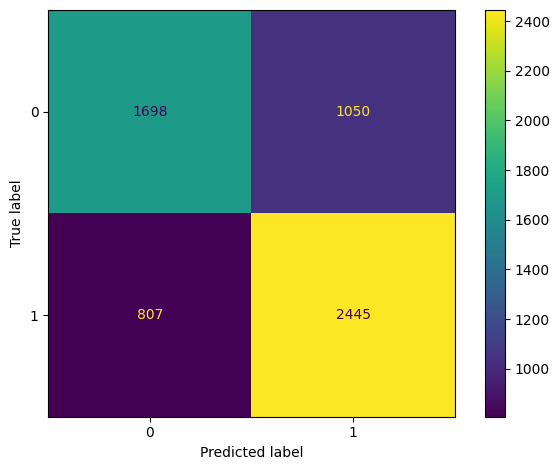

In [22]:
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)

plt.tight_layout()
plt.savefig("work/figures/confusion_matrix.png", dpi=300)
plt.show()

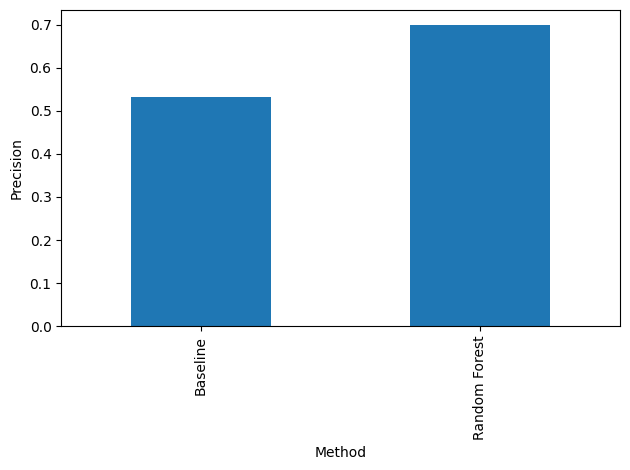

In [23]:
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Method":["Baseline","Random Forest"],
    "Precision":[baseline_precision, rf_precision]
})

comparison.plot(
    x="Method",
    y="Precision",
    kind="bar",
    legend=False
)

plt.ylabel("Precision")

plt.tight_layout()
plt.savefig("work/figures/model_vs_baseline.png", dpi=300)
plt.show()

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Error Analysis and Interpretation

lthough the Random Forest model performs better than the baseline, prediction errors still occur. Some pages are incorrectly classified because their performance is influenced by factors that are not represented in the available dataset, such as seasonal demand, algorithm updates, or changes in user behaviour.

Feature importance indicates that impressions, average search position, and content age contribute most to the model's predictions. However, these importance values describe statistical relationships rather than causal effects.

The model should therefore be used as a decision-support tool that helps editors prioritize pages for review instead of automatically deciding which pages must be refreshed. Human review remains necessary before any content changes are made.

In [24]:
importance = pd.DataFrame({

    "Feature":X.columns,
    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,impressions_90d,0.170230
3,avg_position,0.157938
4,content_age_days,0.111214
9,char_count,0.089051
8,word_count,0.086283
11,scroll_rate,0.068967
2,ctr,0.064851
1,clicks_90d,0.051432
5,search_volume,0.042714
6,competition,0.040992


Show Wrong Predictions

In [25]:
errors = X_test.copy()

errors["Actual"] = y_test.values
errors["Predicted"] = predictions

errors = errors[
    errors["Actual"] != errors["Predicted"]
]

print("Total Misclassified Pages:", len(errors))

errors.head(10)

Total Misclassified Pages: 1857


,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,search_volume,competition,cpc,word_count,char_count,...,ai_traffic_pct,content_type_feedly article,content_type_keyword article,main_intent_informational,main_intent_navigational,main_intent_transactional,competition_level_LOW,competition_level_MEDIUM,Actual,Predicted
2110,511,2,0.39,15.0,223,0.0,0.00,0.00,6466.0,42912.0,...,0.00,False,True,True,False,False,True,False,0,1
9902,127,0,0.00,18.3,175,20.0,0.00,0.00,2892.0,19032.0,...,0.00,False,True,True,False,False,True,False,0,1
27201,66,0,0.00,45.5,310,20.0,0.13,0.00,4162.0,24550.0,...,0.00,False,True,False,False,False,True,False,1,0
25967,373,0,0.00,60.4,502,0.0,0.00,0.00,0.0,0.0,...,100.00,False,True,True,False,False,True,False,1,0
26973,595,1,0.17,5.2,112,10.0,0.00,0.00,2602.0,18454.0,...,0.00,False,True,False,False,False,True,False,0,1
12628,40521,46,0.11,32.7,211,0.0,0.00,0.00,4583.0,29476.0,...,0.98,False,True,True,False,False,True,False,1,0
13530,158,0,0.00,23.4,460,390.0,0.47,0.38,0.0,0.0,...,0.00,False,True,True,False,False,False,True,1,0
17195,3131,1,0.03,21.2,139,0.0,0.00,0.00,5572.0,37798.0,...,0.00,False,True,True,False,False,True,False,0,1
19583,1103,1,0.09,9.6,175,10.0,0.23,0.04,2689.0,17896.0,...,0.00,False,True,True,False,False,True,False,0,1
17941,510,3,0.59,12.0,112,10.0,0.39,0.00,2363.0,16377.0,...,0.00,False,True,False,False,True,False,True,0,1


Feature Importance Plot

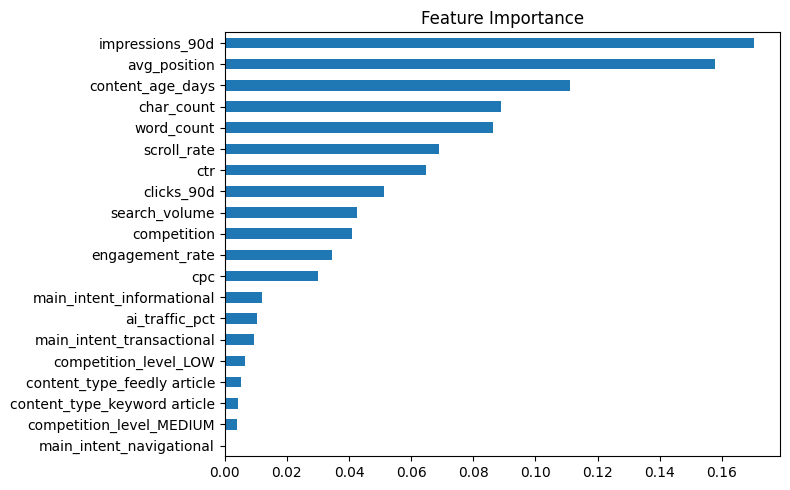

In [26]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values()

importance.plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")

plt.tight_layout()
plt.savefig("work/figures/feature_importance.png", dpi=300)
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.